# M8.3J — Single-view block freeze

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
**Not in Final Report** — M9 imports `m8_single_view_block_freeze()`.

One-shot train / val / **test** on the frozen interpretive triad. Writes JSON + CSV under `checkpoints/m8/m08_3j_single_view_freeze/`.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache


In [3]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import torch

from tomography_ml import get_device
from tomography_ml.gummybear_data_catalog.task_dataset import build_task_dataset
from tomography_ml.studies import M8_CANONICAL_LR_BY_ARCH
import tomography_ml_validation.milestone_08.validation as m8_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

SMOKE = True
RUN_STUDY = None  # None = auto (run when runs CSV missing)
BASE_SEED = 0
NUM_EPOCHS = 40 if SMOKE else 200
EARLY_STOP = 25 if SMOKE else 40

device = get_device()
print(f"device={device}")
print("canonical LRs", M8_CANONICAL_LR_BY_ARCH)


device=mps
canonical LRs {'pooled': 0.001, 'fourier': 0.03, 'flatten': 0.0003}


In [4]:
from tomography_ml_validation.milestone_08 import (
    assert_win3j_freeze_contract,
    freeze_record_dataframe,
    load_m8_catalog_rows,
    load_win3j_results,
    plot_win3j_results,
    run_win3j_freeze_study,
    summarize_win3j,
    win3j_results_dir,
)
from tomography_ml.localization import win3j_single_view_freeze

results_dir = win3j_results_dir(ROOT)
N_REPEAT = 1  # formal one-shot freeze study


## Milestone 8 Step 3J freeze contract

In [5]:
display(freeze_record_dataframe(win3j_single_view_freeze()))
print(assert_win3j_freeze_contract())
run_installed_pytest_test(m8_validation, "test_m8_3j_single_view_freeze_binds_delta_and_per_view_zscore")


,architecture,representation_name,x_field,normalisation_name,image_normalize,phantom_family_reference,optical_regime_reference,optical_setup_id_reference,keep_angles_deg,batch_size,...,lr_primary,lr_positive_baseline,lr_negative_control,library_class,positive_baseline,negative_control,restoration_note,observability_note,selection_rationale,freeze_fields
0,"{'selected_variant': 'fourier_base_mlp', 'spat...",delta,anomaly_ref,per_image_zscore,per_image_zscore,gummybear,high,opt_m8_high_001,180.0,16,...,0.03,0.0003,0.001,LocalizerSingleViewFourier,flatten_base_mlp,pooled_base_base,win3f_delta_excellent_observed_degraded;restor...,report_RMSE_total_and_per_axis_X_Y_Z;single_vi...,architecture_from_win3e;normalisation_per_view...,"(architecture, representation, normalisation, ..."


{'selected_variant': 'fourier_base_mlp', 'x_field': 'anomaly_ref', 'image_normalize': 'per_image_zscore', 'keep_angles_deg': 180.0, 'optical_setup_id_reference': 'opt_m8_high_001', 'library_class': 'LocalizerSingleViewFourier', 'n_freeze_fields': 6}
M8.3J
Test executed: test_m8_3j_single_view_freeze_binds_delta_and_per_view_zscore()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_08/validation.py . [100%]
============================== 1 passed in 1.95s ===============================

Test proves: Milestone 8 Step 3J single-view freeze binds architecture, delta, and per-view
             z-score.


## Train / val / test study

In [6]:
rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
summary_df, runs_df = load_win3j_results(ROOT)
should_run = RUN_STUDY if RUN_STUDY is not None else (runs_df is None or runs_df.empty)
if should_run:
    summary_df, runs_df, _ = run_win3j_freeze_study(
        rows,
        device=device,
        num_epochs=NUM_EPOCHS,
        early_stop_patience=EARLY_STOP,
        results_dir=results_dir,
        repo_root=ROOT,
        n_repeat=N_REPEAT,
        base_seed=BASE_SEED,
    )
else:
    print("Loaded existing runs CSV — set RUN_STUDY=True to retrain.")
display(summary_df)


  fourier_base_mlp rep 1 epoch 001/40  train_loss=29.42525  val_RMSE=3.5714  best=3.5714*  stall=0/25
  fourier_base_mlp rep 1 epoch 002/40  train_loss=8.85937  val_RMSE=2.6147  best=2.6147*  stall=0/25
  fourier_base_mlp rep 1 epoch 003/40  train_loss=5.20181  val_RMSE=1.9246  best=1.9246*  stall=0/25
  fourier_base_mlp rep 1 epoch 004/40  train_loss=3.23952  val_RMSE=1.6241  best=1.6241*  stall=0/25
  fourier_base_mlp rep 1 epoch 005/40  train_loss=2.69000  val_RMSE=1.5559  best=1.5559*  stall=0/25
  fourier_base_mlp rep 1 epoch 006/40  train_loss=1.98286  val_RMSE=1.5564  best=1.5559   stall=1/25
  fourier_base_mlp rep 1 epoch 007/40  train_loss=1.98676  val_RMSE=1.6542  best=1.5559   stall=2/25
  fourier_base_mlp rep 1 epoch 008/40  train_loss=1.80173  val_RMSE=1.6310  best=1.5559   stall=3/25
  fourier_base_mlp rep 1 epoch 009/40  train_loss=1.90380  val_RMSE=1.3735  best=1.3735*  stall=0/25
  fourier_base_mlp rep 1 epoch 010/40  train_loss=1.46917  val_RMSE=1.4196  best=1.3735   

,experiment_id,win,architecture_factor,hypothesis,head_type,downsample,encoder_channels,architecture_config,parameter_count,feature_map_hw,...,validation_RMSE_Z_std,test_RMSE_X_mean,test_RMSE_X_std,test_RMSE_Y_mean,test_RMSE_Y_std,test_RMSE_Z_mean,test_RMSE_Z_std,variant,n_repeat,seeds
1,win3j__flatten_base_mlp,3J,single_view_block_freeze,freeze_before_multi_view_fusion,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_mlp"", ""head_type"":...",134249859,"(128, 128)",...,0.0,0.833856,0.0,0.752404,0.0,0.820955,0.0,flatten_base_mlp,1,0
0,win3j__fourier_base_mlp,3J,single_view_block_freeze,freeze_before_multi_view_fusion,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_mlp"", ""head_type"":...",40323,"(128, 128)",...,0.0,0.860111,0.0,1.216169,0.0,0.902978,0.0,fourier_base_mlp,1,0
2,win3j__pooled_base_base,3J,single_view_block_freeze,freeze_before_multi_view_fusion,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,"(128, 128)",...,0.0,2.857328,0.0,1.922306,0.0,3.431434,0.0,pooled_base_base,1,0


## Results

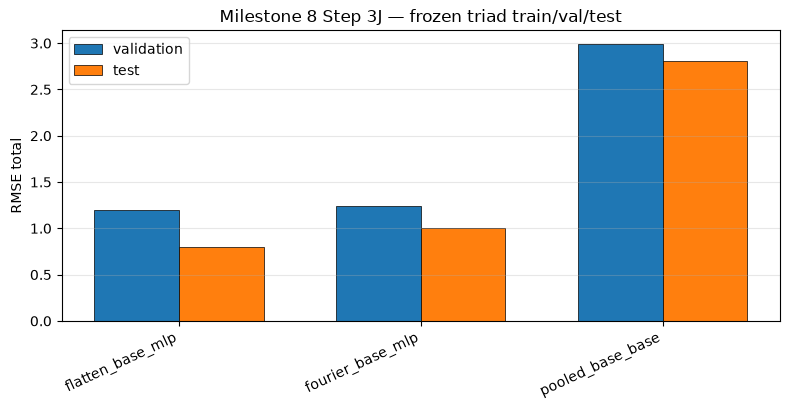

- flatten_base_mlp: val=1.199, test=0.803.

- fourier_base_mlp: val=1.236, test=1.006.

- pooled_base_base: val=2.989, test=2.807.

- Freeze record written to `checkpoints/m8/m08_3j_single_view_freeze/` — do not silently retune for M9.

In [7]:
if summary_df is not None and not summary_df.empty:
    fig = plot_win3j_results(summary_df)
    plt.show()
    for line in summarize_win3j(summary_df):
        display(Markdown(f"- {line}"))
